In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\diabetes-dataset.csv")

In [3]:
x = df.iloc[: , 0:8]
y = df.iloc[: , -1]
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [54]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
968,7,195,70,33,145,25.1,0.163,55
240,1,91,64,24,0,29.2,0.192,21
819,5,0,80,32,0,41.0,0.346,37
692,2,121,70,32,95,39.1,0.886,23
420,1,119,88,41,170,45.3,0.507,26
...,...,...,...,...,...,...,...,...
1130,3,123,100,35,240,57.3,0.880,22
1294,0,100,70,26,50,30.8,0.597,21
860,1,100,66,29,196,32.0,0.444,42
1459,4,95,64,0,0,32.0,0.161,31


In [47]:
ls = Lasso(alpha=0.001)

In [48]:
ls.fit(x_train , y_train)

,alpha,0.001
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [49]:
y_pred = ls.predict(x_test)

In [50]:
y_test

1860    1
353     0
1333    1
905     1
1289    1
       ..
965     0
1284    0
1739    0
261     1
535     1
Name: Outcome, Length: 400, dtype: int64

In [51]:
y_pred

array([ 0.48404546,  0.04419836,  0.8027907 ,  0.595932  ,  0.55506045,
        0.51368786,  0.51580868,  0.25882897,  0.19026343,  0.27214094,
        0.81117645,  0.02658841,  0.95204071,  0.3185827 ,  0.41148968,
        0.31698625,  0.60297983,  0.24611818,  0.18753794,  0.36103022,
        0.3754816 ,  0.21676078,  0.47791609,  0.13787696,  0.34095533,
        0.42799174,  0.4186367 , -0.21999161,  0.22760524,  0.1588083 ,
        0.41246928,  0.21569634,  0.24226005,  0.45805386,  0.18975841,
       -0.10970876,  0.38594255,  0.6000614 ,  0.15462045,  0.31120102,
        0.16783144, -0.12550721,  0.23428718,  0.00696236,  0.93064968,
        0.22759244,  0.27432962,  0.27078521,  0.21705302,  0.6694971 ,
        0.44462696,  0.52494346,  0.51435973,  0.79027869,  0.34171939,
        0.24381021,  0.62136087,  0.45428073,  0.39403942,  0.6030657 ,
        0.36949128,  0.34614761, -0.04413887,  0.15114748,  0.46433648,
        0.84802916,  0.28103918,  0.41781659,  0.58917361,  0.36

In [52]:
r2_score(y_test , y_pred)

0.28787949562907433

In [53]:
ls.coef_

array([ 0.02076793,  0.0057641 , -0.00196385,  0.00108866, -0.00028198,
        0.01189935,  0.09803222,  0.00272088])

### How coefficient are changed ?

In [55]:
coefs = []
r2_scores = []

for i in [0, 0.1, 1, 10]:
    reg = Lasso(alpha=i)
    reg.fit(x_train, y_train)

    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(x_test)
    r2_scores.append(r2_score(y_test, y_pred))

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.276e+02, tolerance: 3.568e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead

In [58]:
coefs

[[0.02094208855681783,
  0.00575855670383852,
  -0.001971602467244148,
  0.0010687105299953426,
  -0.0002856889153371018,
  0.011895187999195889,
  0.10817449845486977,
  0.002692139654181633],
 [0.009485054608984857,
  0.005809330513121439,
  -0.0012193381674267935,
  0.00092611111338726,
  -0.000219625689122366,
  0.010430933060110979,
  0.0,
  0.003580707439774046],
 [0.0, 0.005651746616951674, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]

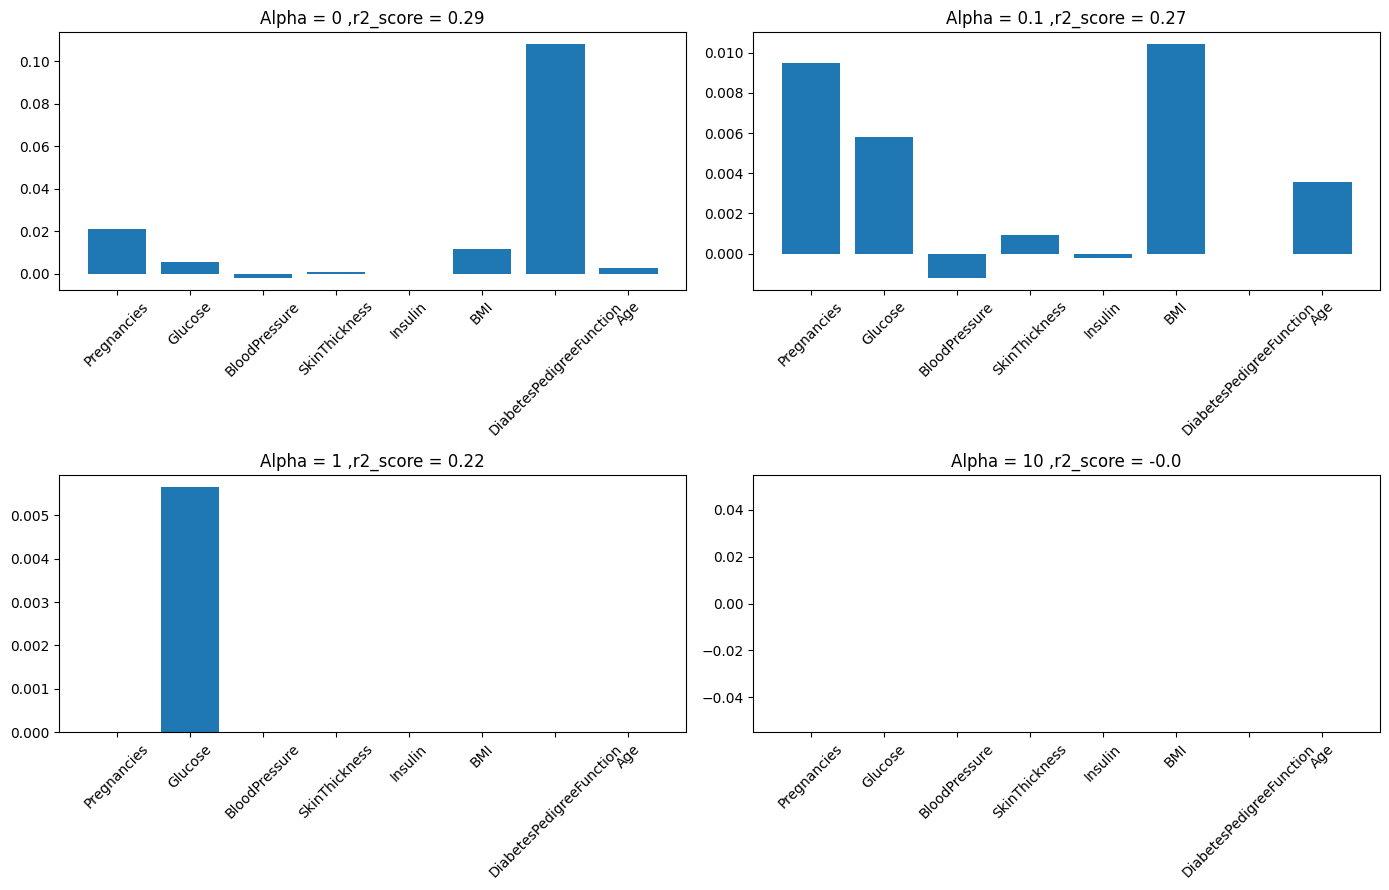

In [57]:
plt.figure(figsize=(14, 9))

plt.subplot(221)
plt.bar(x.columns, coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0], 2)))
plt.xticks(rotation=45)

plt.subplot(222)
plt.bar(x.columns, coefs[1])
plt.title('Alpha = 0.1 ,r2_score = {}'.format(round(r2_scores[1], 2)))
plt.xticks(rotation=45)

plt.subplot(223)
plt.bar(x.columns, coefs[2])
plt.title('Alpha = 1 ,r2_score = {}'.format(round(r2_scores[2], 2)))
plt.xticks(rotation=45)

plt.subplot(224)
plt.bar(x.columns, coefs[3])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[3], 2)))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Higher coeff are affected more 

In [59]:
alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

coefs = []

for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(x_train, y_train)

    coefs.append(reg.coef_.tolist())

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.276e+02, tolerance: 3.568e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead

In [60]:

input_array = np.array(coefs)

coef_df = pd.DataFrame(input_array, columns=x.columns)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
alpha,,,,,,,,
0.0000,0.020942,0.005759,-0.001972,0.001069,-0.000286,0.011895,0.108174,0.002692
0.0001,0.020925,0.005759,-0.001971,0.001071,-0.000285,0.011896,0.107160,0.002695
0.0010,0.020768,0.005764,-0.001964,0.001089,-0.000282,0.011899,0.098032,0.002721
0.0100,0.019200,0.005814,-0.001894,0.001268,-0.000249,0.011937,0.006753,0.002980
0.1000,0.009485,0.005809,-0.001219,0.000926,-0.000220,0.010431,0.000000,0.003581
1.0000,0.000000,0.005652,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
10.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
100.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1000.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
